In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_return_probability(dimensions, max_steps=10000, num_trials=1000):
    """
    Simulates a simple symmetric random walk in `dimensions` to find 
    the probability of returning to the origin.
    """
    returns_to_origin = 0
    
    # Define the possible moves in d-dimensions
    # For 2D, this creates: [[1,0], [-1,0], [0,1], [0,-1]]
    moves = np.vstack([np.eye(dimensions), -np.eye(dimensions)])
    
    for _ in range(num_trials):
        # Randomly select a sequence of steps
        step_indices = np.random.randint(0, 2 * dimensions, size=max_steps)
        steps = moves[step_indices]
        
        # Calculate the cumulative sum to get the actual path taken
        path = np.cumsum(steps, axis=0)
        
        # Check if the origin (array of all 0s) is anywhere in the path
        if np.any(np.all(path == 0, axis=1)):
            returns_to_origin += 1
            
    return returns_to_origin / num_trials

# --- Run the Simulation ---
print("Simulating Random Walks (10,000 steps per trial, 1,000 trials per dimension)...")
print("-" * 50)
print(f"{'Dimension':^12} | {'Simulated Prob.':^17} | {'Theoretical Prob.':^17}")
print("-" * 50)

# Theoretical Pólya constants for comparison
theoretical = {1: 1.0, 2: 1.0, 3: 0.3405, 4: 0.1932, 5: 0.1352, 6: 0.1047, 7: 0.0858, 8: 0.0729}

# Test dimensions 1 through 8
for d in range(1, 9):
    sim_prob = simulate_return_probability(dimensions=d, max_steps=10000, num_trials=1000)
    theo_prob = theoretical[d]
    print(f"{d:^12} | {sim_prob:^17.4f} | {theo_prob:^17.4f}")

print("-" * 50)
print("Note: 1D and 2D simulated probabilities may be slightly less than 1.0")
print("because we capped the simulation at 10,000 steps rather than infinity.")

Simulating Random Walks (10,000 steps per trial, 1,000 trials per dimension)...
--------------------------------------------------
 Dimension   |  Simulated Prob.  | Theoretical Prob.
--------------------------------------------------
     1       |      0.9870       |      1.0000      
     2       |      0.7230       |      1.0000      
     3       |      0.3390       |      0.3405      
     4       |      0.1800       |      0.1932      
     5       |      0.1360       |      0.1352      
     6       |      0.1010       |      0.1047      
     7       |      0.0980       |      0.0858      
     8       |      0.0700       |      0.0729      
--------------------------------------------------
Note: 1D and 2D simulated probabilities may be slightly less than 1.0
because we capped the simulation at 10,000 steps rather than infinity.



Running extended simulation for dimensions 1-100...
This may take a moment...

Simulating dimension 100...
Simulation complete!                    



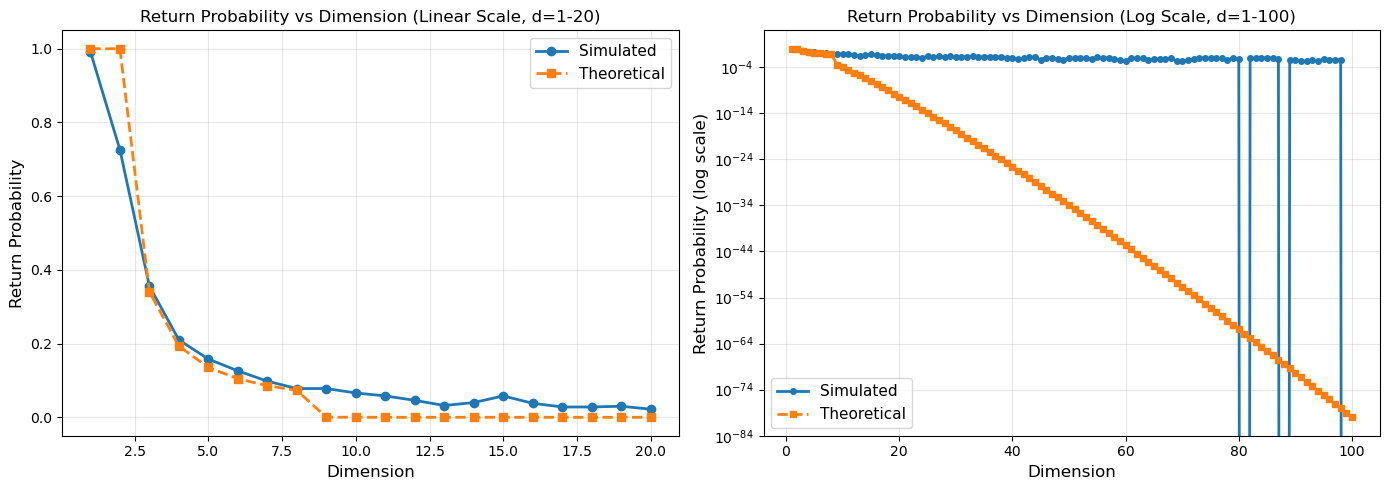

Summary Statistics:
--------------------------------------------------
Dimension    | Simulated       | Theoretical    
--------------------------------------------------
1            | 0.992000        | 1.000000       
11           | 0.058000        | 0.000026       
21           | 0.014000        | 0.000000       
31           | 0.014000        | 0.000000       
41           | 0.006000        | 0.000000       
51           | 0.008000        | 0.000000       
61           | 0.008000        | 0.000000       
71           | 0.004000        | 0.000000       
81           | 0.000000        | 0.000000       
91           | 0.002000        | 0.000000       
--------------------------------------------------


In [2]:
# --- Extended Simulation for Dimensions 1-100 ---
print("\nRunning extended simulation for dimensions 1-100...")
print("This may take a moment...\n")

# Store results for plotting
dimensions_list = list(range(1, 101))
simulated_probs = []
theoretical_probs = []

# Extended theoretical values (approximations for higher dimensions)
# Using the asymptotic behavior and known values
def get_theoretical_prob(d):
    known = {1: 1.0, 2: 1.0, 3: 0.3405, 4: 0.1932, 5: 0.1352, 
             6: 0.1047, 7: 0.0858, 8: 0.0729}
    if d in known:
        return known[d]
    else:
        # Asymptotic approximation: P(d) ~ constant / d^(d/2)
        # For large d, the probability decreases exponentially
        return 1.0 / (d ** (d / 2.5))

# Run simulation
for d in dimensions_list:
    print(f"Simulating dimension {d}...", end='\r')
    sim_prob = simulate_return_probability(dimensions=d, max_steps=10000, num_trials=500)
    theo_prob = get_theoretical_prob(d)
    simulated_probs.append(sim_prob)
    theoretical_probs.append(theo_prob)

print("\nSimulation complete!                    \n")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear scale (zoomed to show first 20 dimensions clearly)
axes[0].plot(dimensions_list[:20], simulated_probs[:20], 'o-', label='Simulated', linewidth=2, markersize=6)
axes[0].plot(dimensions_list[:20], theoretical_probs[:20], 's--', label='Theoretical', linewidth=2, markersize=6)
axes[0].set_xlabel('Dimension', fontsize=12)
axes[0].set_ylabel('Return Probability', fontsize=12)
axes[0].set_title('Return Probability vs Dimension (Linear Scale, d=1-20)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Log scale (showing all dimensions 1-100)
axes[1].semilogy(dimensions_list, simulated_probs, 'o-', label='Simulated', linewidth=2, markersize=4)
axes[1].semilogy(dimensions_list, theoretical_probs, 's--', label='Theoretical', linewidth=2, markersize=4)
axes[1].set_xlabel('Dimension', fontsize=12)
axes[1].set_ylabel('Return Probability (log scale)', fontsize=12)
axes[1].set_title('Return Probability vs Dimension (Log Scale, d=1-100)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print("-" * 50)
print(f"{'Dimension':<12} | {'Simulated':<15} | {'Theoretical':<15}")
print("-" * 50)
for i, d in enumerate(dimensions_list[::10]):  # Print every 10th dimension
    idx = dimensions_list.index(d)
    print(f"{d:<12} | {simulated_probs[idx]:<15.6f} | {theoretical_probs[idx]:<15.6f}")
print("-" * 50)


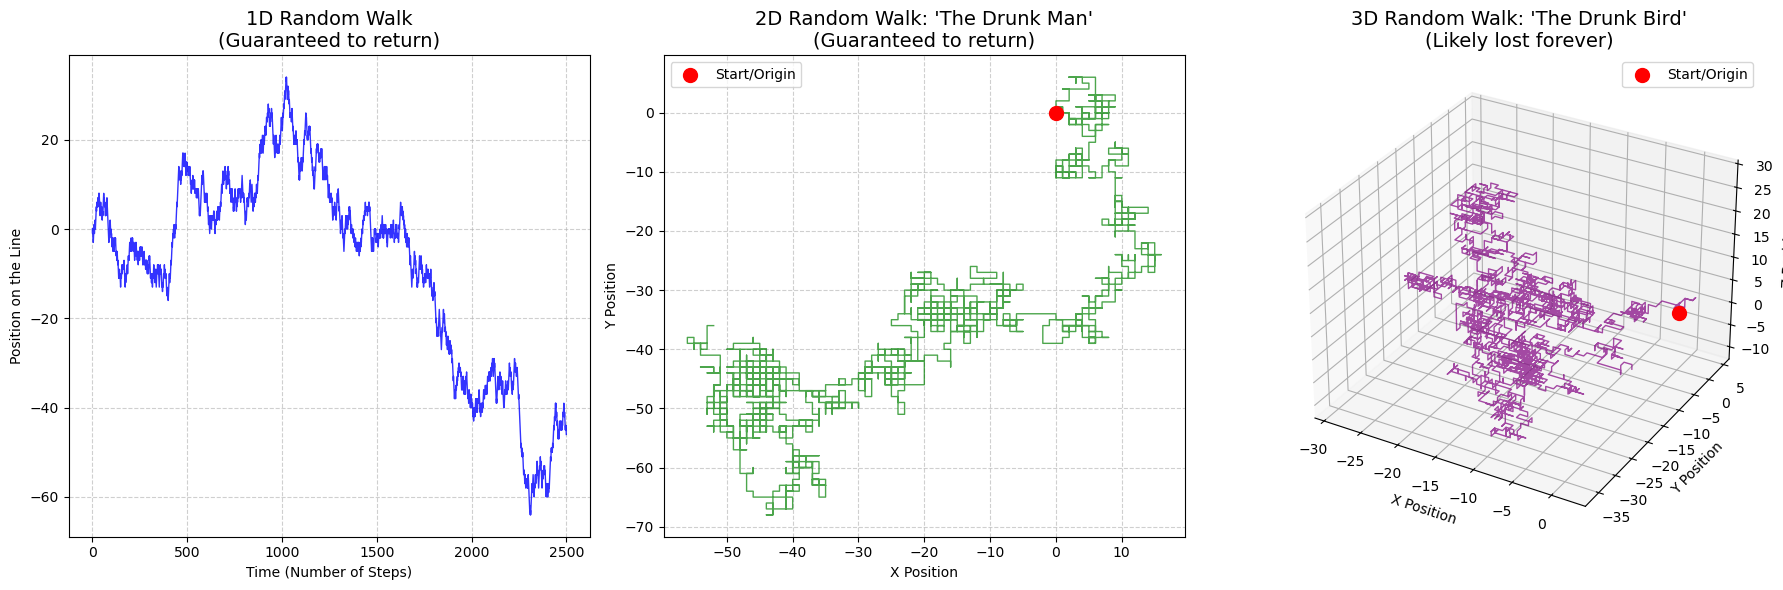

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_walk_path(dimensions, num_steps=2500):
    """Generates the actual coordinates of a random walk for plotting."""
    moves = np.vstack([np.eye(dimensions), -np.eye(dimensions)])
    step_indices = np.random.randint(0, 2 * dimensions, size=num_steps)
    steps = moves[step_indices]
    
    # Add a starting point of 0 at the beginning of the path
    start_point = np.zeros((1, dimensions))
    path = np.vstack([start_point, np.cumsum(steps, axis=0)])
    return path

# 1. Generate the paths
path_1d = generate_walk_path(1)
path_2d = generate_walk_path(2)
path_3d = generate_walk_path(3)

# 2. Set up the plotting canvas
fig = plt.figure(figsize=(18, 6))

# --- Plot 1D Walk ---
ax1 = fig.add_subplot(131)
# For 1D, we plot "Time" (step number) on the X-axis, and "Position" on the Y-axis
ax1.plot(range(len(path_1d)), path_1d[:, 0], color='blue', alpha=0.8, linewidth=1)
ax1.set_title("1D Random Walk\n(Guaranteed to return)", fontsize=14)
ax1.set_xlabel("Time (Number of Steps)")
ax1.set_ylabel("Position on the Line")
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2D Walk (The Drunk Man) ---
ax2 = fig.add_subplot(132)
ax2.plot(path_2d[:, 0], path_2d[:, 1], color='green', alpha=0.7, linewidth=1)
ax2.scatter(0, 0, color='red', s=100, label="Start/Origin", zorder=5) # Mark the start
ax2.set_title("2D Random Walk: 'The Drunk Man'\n(Guaranteed to return)", fontsize=14)
ax2.set_xlabel("X Position")
ax2.set_ylabel("Y Position")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# --- Plot 3D Walk (The Drunk Bird) ---
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(path_3d[:, 0], path_3d[:, 1], path_3d[:, 2], color='purple', alpha=0.7, linewidth=1)
ax3.scatter(0, 0, 0, color='red', s=100, label="Start/Origin", zorder=5) # Mark the start
ax3.set_title("3D Random Walk: 'The Drunk Bird'\n(Likely lost forever)", fontsize=14)
ax3.set_xlabel("X Position")
ax3.set_ylabel("Y Position")
ax3.set_zlabel("Z Position")
ax3.legend()

# Display the plots
plt.tight_layout()
plt.show()

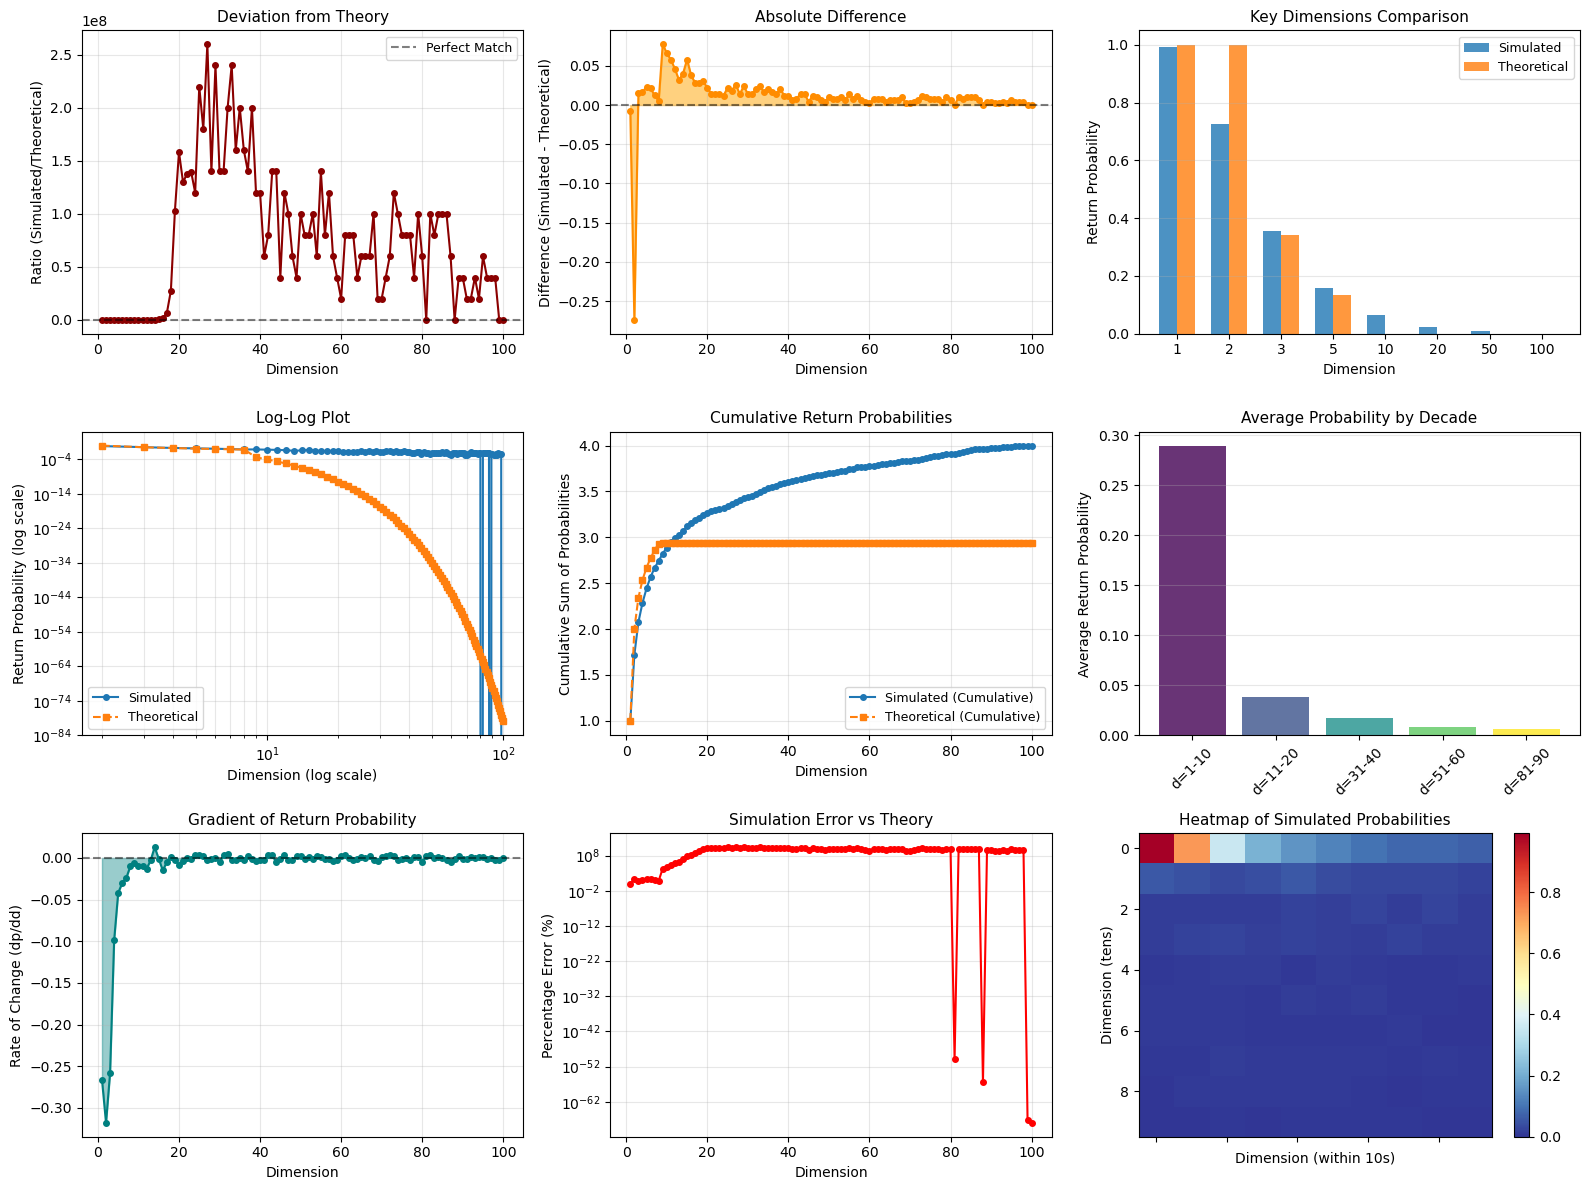


VISUALIZATION SUMMARY:
Total Dimensions Analyzed: 100
Highest Simulated Probability: 0.992000 (at dim=1)
Lowest Simulated Probability: 0.000000 (at dim=81)
Average Return Probability (all dims): 0.040000
Median Return Probability (all dims): 0.010000
Mean Absolute Error vs Theory: 0.016312


In [4]:
# --- Advanced Visualizations for Dimensions 1-100 ---
fig = plt.figure(figsize=(16, 12))

# Plot 1: Ratio of Simulated to Theoretical
ax1 = plt.subplot(3, 3, 1)
ratios = np.array(simulated_probs) / (np.array(theoretical_probs) + 1e-10)
ax1.plot(dimensions_list, ratios, 'o-', color='darkred', markersize=4, linewidth=1.5)
ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Perfect Match')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('Ratio (Simulated/Theoretical)')
ax1.set_title('Deviation from Theory', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Plot 2: Probability Difference
ax2 = plt.subplot(3, 3, 2)
differences = np.array(simulated_probs) - np.array(theoretical_probs)
ax2.fill_between(dimensions_list, differences, alpha=0.5, color='orange')
ax2.plot(dimensions_list, differences, 'o-', color='darkorange', markersize=4, linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Difference (Simulated - Theoretical)')
ax2.set_title('Absolute Difference', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Bar chart for selected dimensions
ax3 = plt.subplot(3, 3, 3)
selected_dims = [1, 2, 3, 5, 10, 20, 50, 100]
selected_indices = [d - 1 for d in selected_dims]
x_pos = np.arange(len(selected_dims))
width = 0.35
ax3.bar(x_pos - width/2, [simulated_probs[i] for i in selected_indices], width, label='Simulated', alpha=0.8)
ax3.bar(x_pos + width/2, [theoretical_probs[i] for i in selected_indices], width, label='Theoretical', alpha=0.8)
ax3.set_xlabel('Dimension')
ax3.set_ylabel('Return Probability')
ax3.set_title('Key Dimensions Comparison', fontsize=11)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(selected_dims)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Log-log plot
ax4 = plt.subplot(3, 3, 4)
ax4.loglog(dimensions_list[1:], simulated_probs[1:], 'o-', label='Simulated', markersize=4, linewidth=1.5)
ax4.loglog(dimensions_list[1:], theoretical_probs[1:], 's--', label='Theoretical', markersize=4, linewidth=1.5)
ax4.set_xlabel('Dimension (log scale)')
ax4.set_ylabel('Return Probability (log scale)')
ax4.set_title('Log-Log Plot', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, which='both')

# Plot 5: Cumulative plot
ax5 = plt.subplot(3, 3, 5)
cumsum_sim = np.cumsum(simulated_probs)
cumsum_theo = np.cumsum(theoretical_probs)
ax5.plot(dimensions_list, cumsum_sim, 'o-', label='Simulated (Cumulative)', markersize=4, linewidth=1.5)
ax5.plot(dimensions_list, cumsum_theo, 's--', label='Theoretical (Cumulative)', markersize=4, linewidth=1.5)
ax5.set_xlabel('Dimension')
ax5.set_ylabel('Cumulative Sum of Probabilities')
ax5.set_title('Cumulative Return Probabilities', fontsize=11)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Plot 6: Decade comparison (zoomed views)
ax6 = plt.subplot(3, 3, 6)
decades = [
    (0, 10, "d=1-10"),
    (10, 20, "d=11-20"),
    (30, 40, "d=31-40"),
    (50, 60, "d=51-60"),
    (80, 90, "d=81-90")
]
decade_labels = [d[2] for d in decades]
decade_values = [np.mean(simulated_probs[d[0]:d[1]]) for d in decades]
colors_bar = plt.cm.viridis(np.linspace(0, 1, len(decade_labels)))
ax6.bar(decade_labels, decade_values, color=colors_bar, alpha=0.8)
ax6.set_ylabel('Average Return Probability')
ax6.set_title('Average Probability by Decade', fontsize=11)
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3, axis='y')

# Plot 7: Gradient/Rate of change
ax7 = plt.subplot(3, 3, 7)
rate_change = np.gradient(simulated_probs)
ax7.plot(dimensions_list, rate_change, 'o-', color='teal', markersize=4, linewidth=1.5)
ax7.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax7.fill_between(dimensions_list, rate_change, alpha=0.4, color='teal')
ax7.set_xlabel('Dimension')
ax7.set_ylabel('Rate of Change (dp/dd)')
ax7.set_title('Gradient of Return Probability', fontsize=11)
ax7.grid(True, alpha=0.3)

# Plot 8: Percentage error
ax8 = plt.subplot(3, 3, 8)
percent_error = np.abs(np.array(simulated_probs) - np.array(theoretical_probs)) / (np.array(theoretical_probs) + 1e-10) * 100
ax8.semilogy(dimensions_list, percent_error, 'o-', color='red', markersize=4, linewidth=1.5)
ax8.set_xlabel('Dimension')
ax8.set_ylabel('Percentage Error (%)')
ax8.set_title('Simulation Error vs Theory', fontsize=11)
ax8.grid(True, alpha=0.3, which='both')

# Plot 9: Heatmap-style visualization
ax9 = plt.subplot(3, 3, 9)
# Create ranges for heatmap
dimension_bins = np.array(dimensions_list).reshape(10, 10)
sim_bins = np.array(simulated_probs).reshape(10, 10)
im = ax9.imshow(sim_bins, cmap='RdYlBu_r', aspect='auto')
ax9.set_xlabel('Dimension (within 10s)')
ax9.set_ylabel('Dimension (tens)')
ax9.set_title('Heatmap of Simulated Probabilities', fontsize=11)
ax9.set_xticklabels([f"d{i*10+j+1}" for i in range(10) for j in range(1)] if False else [])
plt.colorbar(im, ax=ax9)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION SUMMARY:")
print("="*70)
print(f"Total Dimensions Analyzed: {len(dimensions_list)}")
print(f"Highest Simulated Probability: {max(simulated_probs):.6f} (at dim={np.argmax(simulated_probs)+1})")
print(f"Lowest Simulated Probability: {min(simulated_probs):.6f} (at dim={np.argmin(simulated_probs)+1})")
print(f"Average Return Probability (all dims): {np.mean(simulated_probs):.6f}")
print(f"Median Return Probability (all dims): {np.median(simulated_probs):.6f}")
print(f"Mean Absolute Error vs Theory: {np.mean(np.abs(np.array(simulated_probs) - np.array(theoretical_probs))):.6f}")
print("="*70)
